In [1]:
import csv
import pickle
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from dataclasses import dataclass
from absl import logging
logging.set_verbosity(logging.ERROR)

In [2]:
temperatures_csv = '/content/1_Daily_minimum_temps.csv'

with open(temperatures_csv, 'r') as csvfile:
  print(f"Header looks like this:\n\n{csvfile.readline()}")
  print(f"First data point looks like this:\n\n{csvfile.readline()}")
  print(f"Second data point looks like this:\n\n{csvfile.readline()}")

Header looks like this:

Date,Temp

First data point looks like this:

01/01/81,20.7

Second data point looks like this:

01/02/81,17.9



In [3]:
def plot_series(time, series, format = '-', start = 0, end = None):
  plt.plot(time[start:end], series[start:end], format)
  plt.xlabel('Time')
  plt.ylabel('Value')
  plt.grid(True)

Parsing the raw data

In [4]:
def parse_data_from_files(filename):

  times = []
  temperatures = []

  with open(filename) as csvfile:

    reader = csv.reader(csvfile, delimiter = ',')

    next(reader)

    i = 0

    for row in reader:
      times.append(i)
      temperatures.append(float(row[1]))
      i += 1

  return times, temperatures

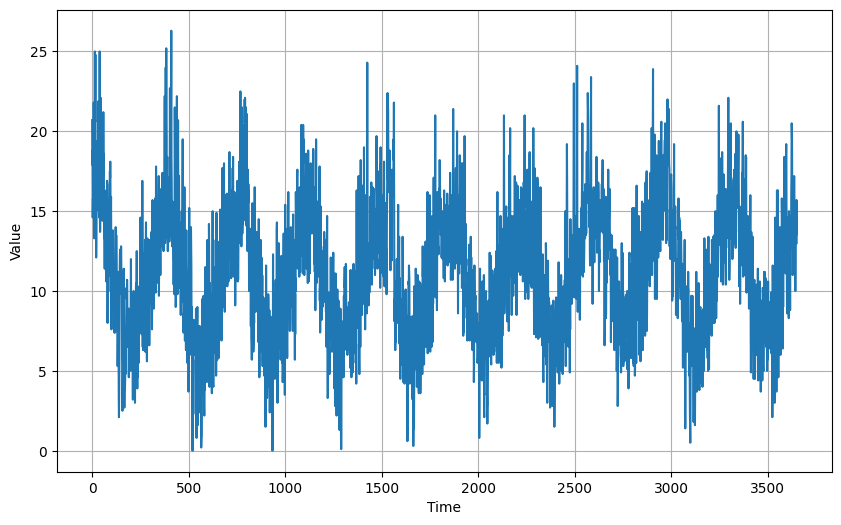

In [5]:
def parse_data_from_files(filename):

  times = []
  temperatures = []

  with open(filename) as csvfile:

    reader = csv.reader(csvfile, delimiter = ',')

    next(reader)

    i = 0

    for row in reader:
      times.append(i)

      cleaned_temp_str = row[1].replace('?', '')
      temperatures.append(float(cleaned_temp_str))
      i += 1

  return times, temperatures


@dataclass
class G:

  temperatures_csv = '/content/1_Daily_minimum_temps.csv'
  times, temperatures = parse_data_from_files(temperatures_csv)
  TIME = np.array(times)
  SERIES = np.array(temperatures)
  SPLIT_TIME = 2500
  WINDOW_SIZE = 64
  BATCH_SIZE = 32
  SHUFFLE_BUFFER_SIZE = 1000


plt.figure(figsize = (10,6))
plot_series(G.TIME, G.SERIES)
plt.show()

Processing the data

In [6]:
def train_val_spit(time, series, time_step = G.SPLIT_TIME):

  time_train = time[:time_step]
  series_train = series[:time_step]
  time_valid = time[time_step:]
  series_valid = series[time_step:]

  return time_train, series_train, time_valid, series_valid


time_train, series_train, time_valid, series_valid = train_val_spit(G.TIME, G.SERIES)

In [7]:
def windowed_dataset(series, window_size = G.WINDOW_SIZE, batch_size = G.BATCH_SIZE, shuffle_buffer = G.SHUFFLE_BUFFER_SIZE):
  ds = tf.data.Dataset.from_tensor_slices(series)
  ds = ds.window(window_size + 1, shift = 1, drop_remainder = True)
  ds = ds.flat_map(lambda w: w.batch(window_size + 1))
  ds = ds.shuffle(shuffle_buffer)
  ds = ds.map(lambda w: (w[:-1], w[-1]))
  ds = ds.batch(batch_size).prefetch(1)
  return ds


train_set = windowed_dataset(series_train, window_size = G.WINDOW_SIZE, batch_size = G.BATCH_SIZE, shuffle_buffer = G.SHUFFLE_BUFFER_SIZE)



Defining the model architecture

In [10]:
import tensorflow as tf

def create_uncompiled_model():

    model = tf.keras.Sequential([
        tf.keras.Input(shape=(None, 1)),
        tf.keras.layers.Conv1D(
            filters=60,
            kernel_size=5,
            strides=1,
            padding='causal',
            activation='relu'
        ),
        tf.keras.layers.LSTM(60, return_sequences=True),
        tf.keras.layers.LSTM(60),
        tf.keras.layers.Dense(30, activation='relu'),
        tf.keras.layers.Dense(15, activation='relu'),
        tf.keras.layers.Dense(1)
    ])

    return model

In [11]:
uncompiled_model = create_uncompiled_model()

for X, y in train_set.take(1):
    print(f"Testing model prediction with input of shape {X.shape}...")
    y_pred = uncompiled_model.predict(X)

y_pred_shape = y_pred.squeeze().shape

assert y_pred_shape == y.shape, (
    f"Squeezed predicted y shape = {y_pred_shape} "
    f"whereas actual y shape = {y.shape}."
)

print("Your current architecture is compatible with the windowed dataset! :)")

Testing model prediction with input of shape (32, 64)...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 331ms/step
Your current architecture is compatible with the windowed dataset! :)


Adjusting the learning rate

In [12]:
def adjust_learning_rate(dataset):

  model = create_uncompiled_model()

  lr_schedule = tf.keras.callbacks.LearningRateScheduler(lambda epoch: 1e-4 * 10**(epoch / 20))

  optimizer = tf.keras.optimizers.SGD(momentum = 0.9)

  model.compile(loss = 'mse',
                optimizer = optimizer,
                metrics = ['mae'])

  history = model.fit(dataset, epochs = 100, callbacks = [lr_schedule])

  return history

In [13]:
lr_history = adjust_learning_rate(train_set)

Epoch 1/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step - loss: 64.8889 - mae: 6.5601 - learning_rate: 1.0000e-04
Epoch 2/100
 1/77 ━━━━━━━━━━━━━━━━━━━━ 12s 163ms/step - loss: 14.3551 - mae: 2.9615

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


77/77 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 11.5441 - mae: 2.6345 - learning_rate: 1.1220e-04
Epoch 3/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - loss: 9.4084 - mae: 2.4207 - learning_rate: 1.2589e-04
Epoch 4/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - loss: 8.3054 - mae: 2.2585 - learning_rate: 1.4125e-04
Epoch 5/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 7.8284 - mae: 2.2057 - learning_rate: 1.5849e-04
Epoch 6/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 7.8832 - mae: 2.1980 - learning_rate: 1.7783e-04
Epoch 7/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - loss: 8.1216 - mae: 2.2493 - learning_rate: 1.9953e-04
Epoch 8/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 7.2355 - mae: 2.1147 - learning_rate: 2.2387e-04
Epoch 9/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 7s 93ms/step - loss: 6.9406 - mae: 2.0740 - learning_rate: 2.5119e-04
Epoch 10/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 6.5707 - mae: 2.0143 - learning_rate: 2.8184e-04
Epoch 11/100
77/77 ━━━━━━━━━━

(np.float64(0.0001), np.float64(10.0), np.float64(0.0), np.float64(10.0))

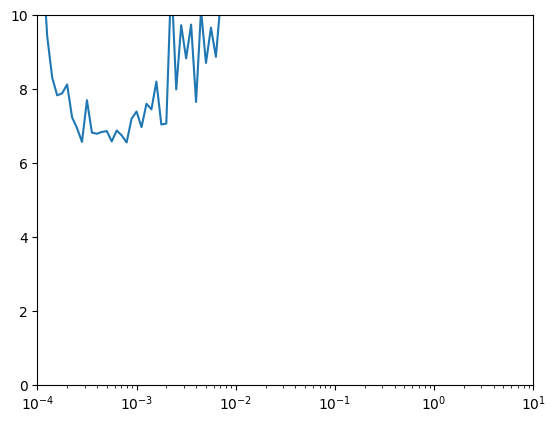

In [16]:
if 'lr' in lr_history.history:
    lrs = lr_history.history['lr']
elif 'learning_rate' in lr_history.history:
    lrs = lr_history.history['learning_rate']
else:

    initial_lr = 1e-4
    epochs_trained = len(lr_history.history['loss'])
    lrs = [initial_lr * (10**(epoch / 20)) for epoch in range(epochs_trained)]

plt.semilogx(lrs, lr_history.history['loss'])

plt.axis([1e-4, 10, 0, 10])

Compiling the model

In [17]:
def create_model():

  model = create_uncompiled_model()

  model.compile(loss = 'mse',
                optimizer = tf.keras.optimizers.SGD(learning_rate = 1e-3, momentum = 0.9),
                metrics = ['mae'])

  return model

In [18]:
model = create_model()

history = model.fit(train_set, epochs = 50)

Epoch 1/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - loss: 28.7049 - mae: 4.1074
Epoch 2/50
 1/77 ━━━━━━━━━━━━━━━━━━━━ 12s 165ms/step - loss: 21.9748 - mae: 3.6130

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


77/77 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - loss: 11.2215 - mae: 2.6240
Epoch 3/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 6s 73ms/step - loss: 7.7182 - mae: 2.1790
Epoch 4/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 7.7696 - mae: 2.1730
Epoch 5/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 7.3043 - mae: 2.1289
Epoch 6/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - loss: 7.2332 - mae: 2.1067
Epoch 7/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - loss: 7.3314 - mae: 2.1357
Epoch 8/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 7.1853 - mae: 2.0926
Epoch 9/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - loss: 7.3014 - mae: 2.1184
Epoch 10/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 6.7337 - mae: 2.0377
Epoch 11/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 6.9892 - mae: 2.0580
Epoch 12/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - loss: 6.8340 - mae: 2.0578
Epoch 13/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - loss: 6.9288 - mae: 2.0697
Epoch 14/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms

Evaluating the forecast

In [19]:
def compute_metrics(true_series, forecast):

    mse = tf.keras.metrics.mean_squared_error(true_series, forecast).numpy()

    mae = tf.keras.metrics.mean_absolute_error(true_series, forecast).numpy()

    return mse, mae

Faster model forecasts

In [20]:
def model_forecast(model, series, window_size):
  ds = tf.data.Dataset.from_tensor_slices(series)
  ds = ds.window(window_size, shift = 1,  drop_remainder = True)
  ds = ds.flat_map(lambda w: w.batch(window_size))
  ds = ds.batch(32).prefetch(1)
  forecast = model.predict(ds)
  return forecast

113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


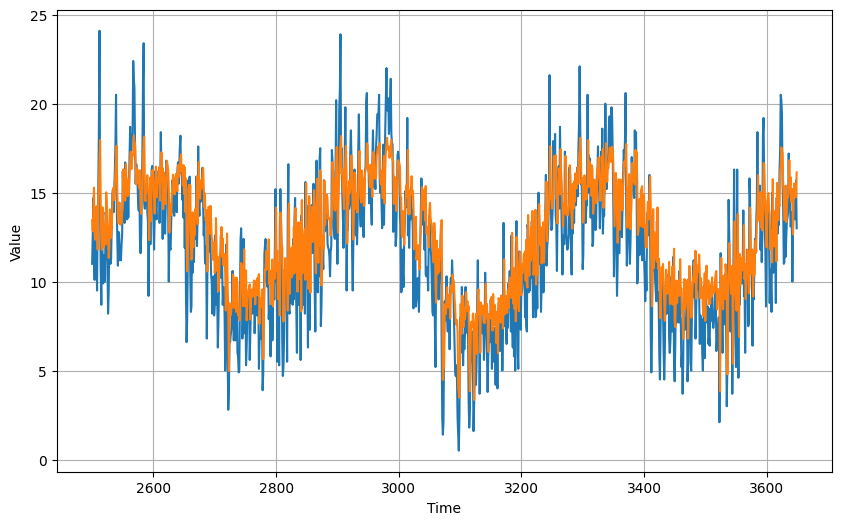

In [21]:
rnn_forecast = model_forecast(model, G.SERIES, G.WINDOW_SIZE).squeeze()

rnn_forecast = rnn_forecast[G.SPLIT_TIME - G.WINDOW_SIZE:-1]

plt.figure(figsize=(10, 6))
plot_series(time_valid, series_valid)
plot_series(time_valid, rnn_forecast)

In [24]:
mse = tf.reduce_mean(tf.square(tf.subtract(series_valid, rnn_forecast))).numpy()
mae = tf.reduce_mean(tf.abs(tf.subtract(series_valid, rnn_forecast))).numpy()

print(f"mse: {mse:.2f}, mae: {mae:.2f} for forecast")

mse: 6.16, mae: 1.96 for forecast
